# Load Libraries

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import math
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_squared_error,mean_absolute_error,r2_score


# Load & Understand the Dataset

In [3]:
df=pd.read_csv('/content/drive/MyDrive/AI_ML/Assessment2/heart_disease.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [7]:
#TO know how many row*columns
df.shape

(1025, 14)

In [8]:
#To get breif summary of numerical columns
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
#To get datatype of columns
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [12]:
#To get columns,non-null count and dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# Train-Test Split

In [103]:
X=df.drop(columns='target')
y=df['target']

In [102]:
X_train_cls,X_test_cls,y_train_cls,y_test_cls=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [84]:
#verify
print(X_train_cls.shape)
print(X_test_cls.shape)
print(y_train_cls.shape)
print(y_test_cls.shape)

(820, 13)
(205, 13)
(820,)
(205,)


# Detecting Missing value

In [85]:
print('X_train:',X_train_cls.isna().sum().sum())
print('X_test:',X_test_cls.isna().sum().sum())
print('y_train:',y_train_cls.isna().sum().sum())
print('y_test:',y_train_cls.isna().sum().sum())

X_train: 0
X_test: 0
y_train: 0
y_test: 0


### Missing value count is 0 hence,No need of imputation

#Detecting & Handling outlier

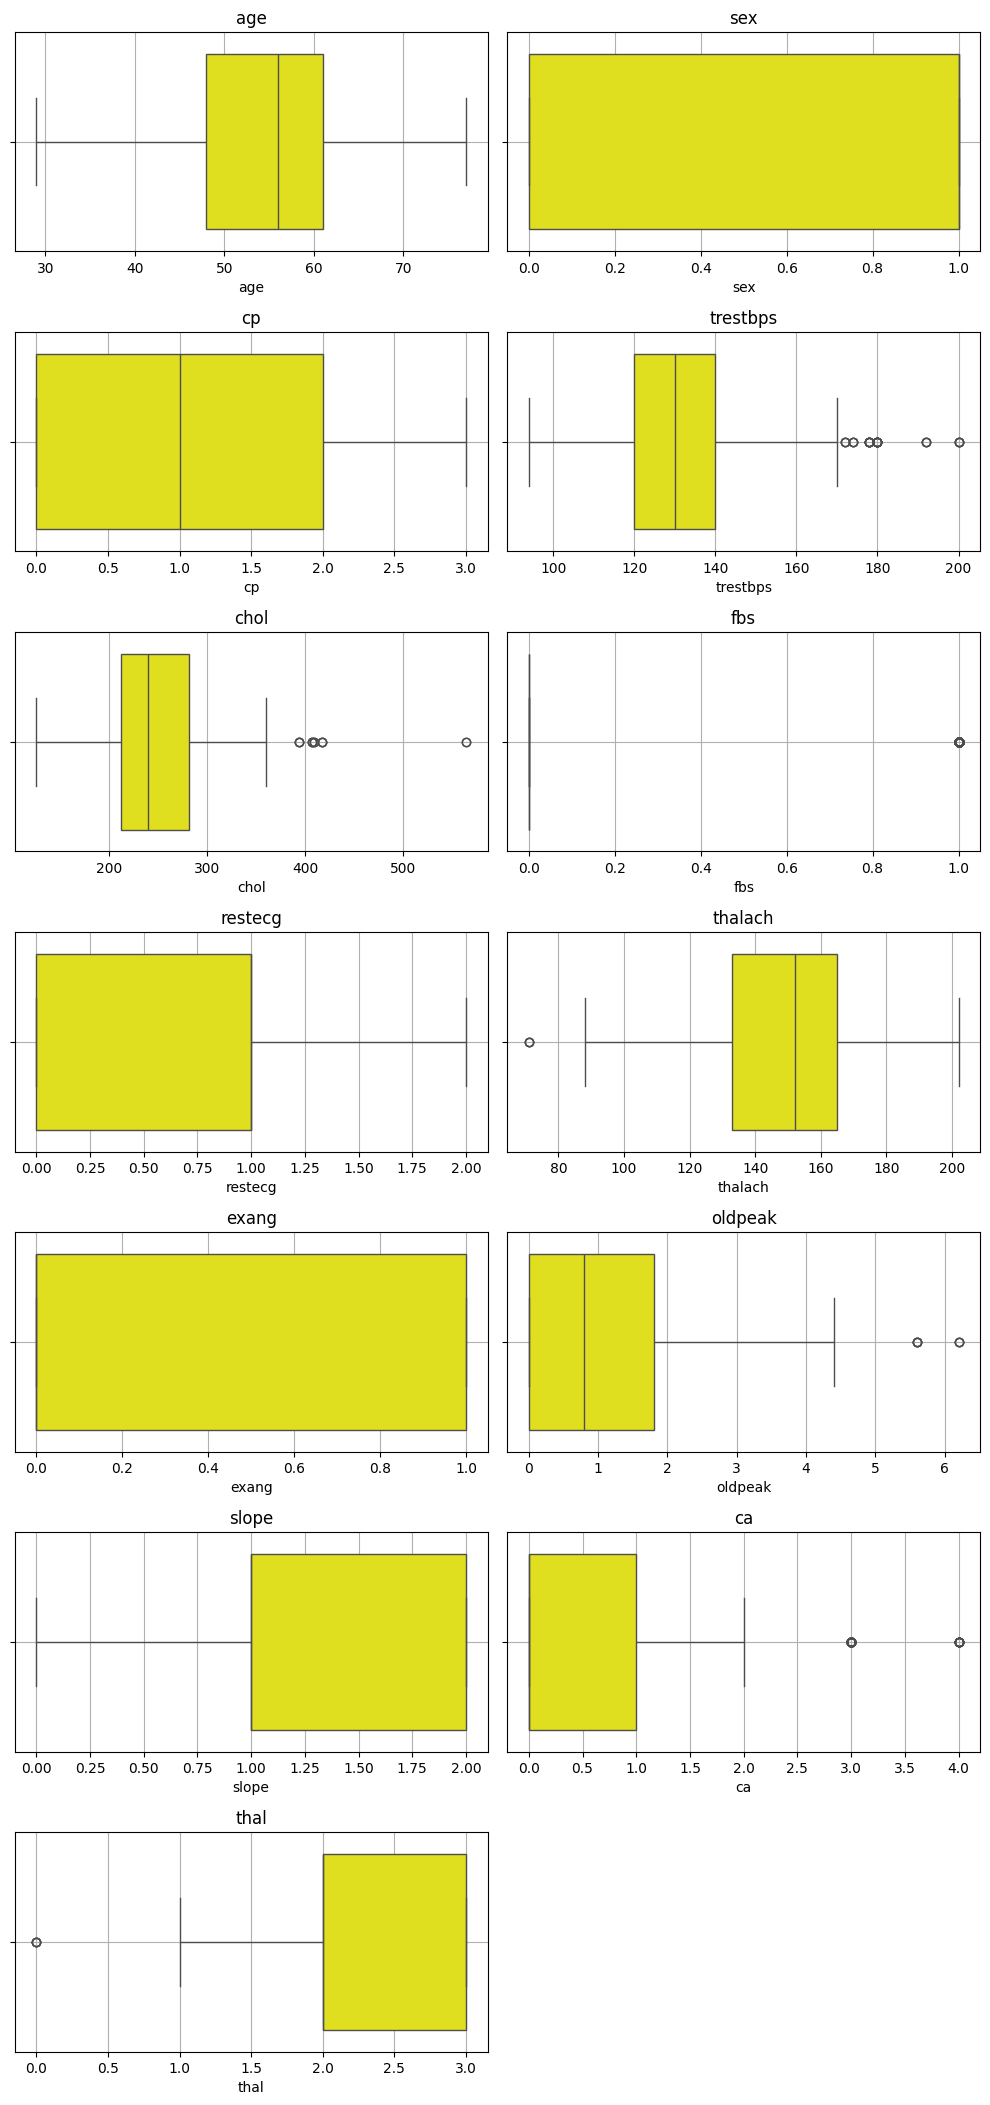

In [86]:
#Detecting outlier using boxplot
row=math.ceil(len(X_train_cls)/2)
plt.figure(figsize=(10,row*3))
for i,col in enumerate(X_train_cls):
  plt.subplot(row,2,i+1)
  sns.boxplot(x=X_train_cls[col],color='yellow')
  plt.title(col)
  plt.grid()
plt.tight_layout()
plt.show()

In [87]:
#Handling outlier using IQR Method
def handle_oultier(col):
  Q1=X_train_cls[col].quantile(0.25)
  Q3=X_train_cls[col].quantile(0.75)
  IQR=Q3-Q1
  lower_b=Q1-1.5*IQR
  upper_b=Q3+1.5*IQR

  #use clip() to handle outliers
  X_train_cls[col]=X_train_cls[col].clip(lower=lower_b,upper=upper_b)
  X_test_cls[col]=X_test_cls[col].clip(lower=lower_b,upper=upper_b)

for col in X_train_cls:
  handle_oultier(col)


### Categorical columns are encoded already in the dataset

# Feature Selection--->Classification

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


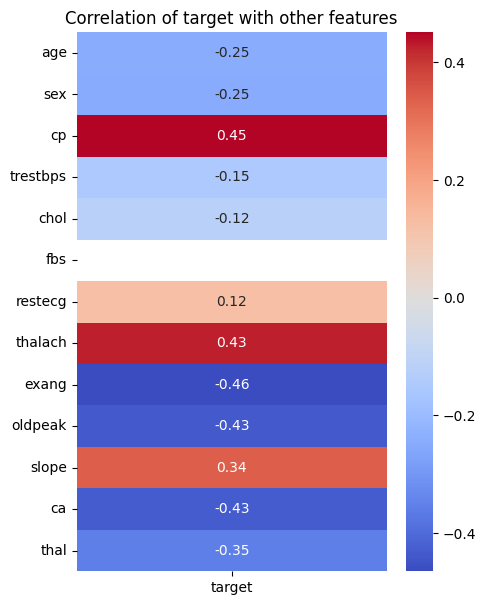

In [88]:
corr=X_train_cls.corrwith(y_train_cls)
plt.figure(figsize=(5,7))
sns.heatmap(corr.to_frame(name='target'),annot=True,cmap='coolwarm')
plt.title('Correlation of target with other features')
plt.show()

In [89]:
corr[lambda x:x.abs()>0.2]

,0
age,-0.246086
sex,-0.247227
cp,0.450837
thalach,0.426588
exang,-0.464727
oldpeak,-0.432816
slope,0.339492
ca,-0.431587
thal,-0.354955


In [90]:
sel_col=['sex','exang','thal']
X_train_cls=X_train_cls[sel_col]
X_test_cls=X_test_cls[sel_col]

# Feature Scaling

In [92]:
scaler=StandardScaler()
X_train_cls_scaled=scaler.fit_transform(X_train_cls)
X_test_cls_scaled=scaler.transform(X_test_cls)

In [93]:
X_train_cls_scaled

array([[-1.50996689, -0.71813066, -0.57454843],
       [-1.50996689,  1.39250426,  1.10206976],
       [ 0.66226618, -0.71813066,  1.10206976],
       ...,
       [-1.50996689, -0.71813066,  1.10206976],
       [ 0.66226618,  1.39250426,  1.10206976],
       [ 0.66226618,  1.39250426, -0.57454843]])

# Class Imbalance

In [143]:
smote=SMOTE(random_state=42)
X_train_cls_scaled, y_train_cls_scaled = smote.fit_resample(X_train_cls_scaled, y_train_cls)

# Model Building

In [145]:
lg=LogisticRegression()
knn=KNeighborsClassifier(n_neighbors=5)
rf=RandomForestClassifier(n_estimators=100,random_state=42)


# Model Training

In [147]:
lg.fit(X_train_cls_scaled,y_train_cls_scaled)
knn.fit(X_train_cls_scaled,y_train_cls_scaled)
rf.fit(X_train_cls_scaled,y_train_cls_scaled)

RandomForestClassifier(random_state=42)

# Model Prediction on test dataset

In [148]:
y_pred_lg=lg.predict(X_test_cls_scaled)
y_pred_knn=knn.predict(X_test_cls_scaled)
y_pred_rf=rf.predict(X_test_cls_scaled)

# Model Evaluation

In [149]:
models={
    'Logisic Regression':y_pred_lg,
    'KNN':y_pred_knn,
    'Random Forest':y_pred_rf
}

**********************Logisic Regression********************************
Accuracy for Logisic Regression is :0.746
Classifcation Report
              precision    recall  f1-score   support

           0       0.74      0.75      0.74       100
           1       0.76      0.74      0.75       105

    accuracy                           0.75       205
   macro avg       0.75      0.75      0.75       205
weighted avg       0.75      0.75      0.75       205



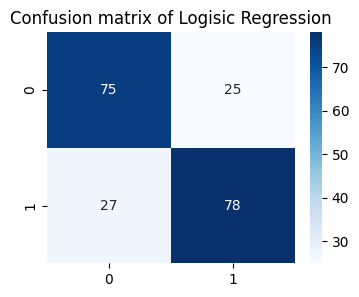

**********************KNN********************************
Accuracy for KNN is :0.751
Classifcation Report
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       100
           1       0.82      0.66      0.73       105

    accuracy                           0.75       205
   macro avg       0.76      0.75      0.75       205
weighted avg       0.76      0.75      0.75       205



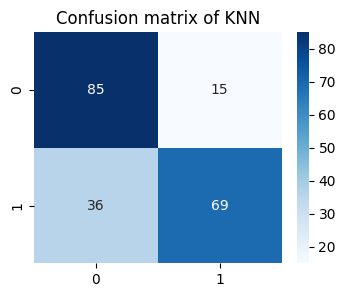

**********************Random Forest********************************
Accuracy for Random Forest is :0.771
Classifcation Report
              precision    recall  f1-score   support

           0       0.76      0.77      0.77       100
           1       0.78      0.77      0.78       105

    accuracy                           0.77       205
   macro avg       0.77      0.77      0.77       205
weighted avg       0.77      0.77      0.77       205



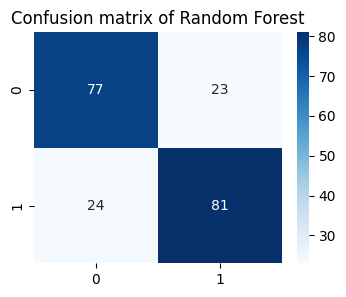

In [150]:
for name,y_pred in models.items():
  print(f'**********************{name}********************************')
  #Accuracy
  accuracy=accuracy_score(y_test_cls,y_pred)
  print(f'Accuracy for {name} is :{accuracy:.3f}')

  #Precision,Recall,F1-Score
  print('Classifcation Report')
  print(classification_report(y_test_cls,y_pred))

  #confusion Matrix
  cm=confusion_matrix(y_test_cls,y_pred)
  plt.figure(figsize=(4,3))
  sns.heatmap(data=cm,annot=True,cmap='Blues')
  plt.title(f'Confusion matrix of {name}')
  plt.show()


# Feature Selction--->Regression


In [104]:
X_reg=X.drop(columns=['chol'])
y_reg=df['chol']

In [106]:
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(X_reg,y_reg,random_state=42,test_size=0.2)

In [115]:
corr_reg=X_train_reg.corrwith(y_train_reg)



In [117]:
corr_reg[lambda x: x.abs()>0.1]

,0
age,0.238369
sex,-0.177799
cp,-0.104164
trestbps,0.153424
restecg,-0.147512


In [120]:
sel_col=['age','sex','trestbps']
X_train_reg=X_train_reg[sel_col]
X_test_reg=X_test_reg[sel_col]

# Feature Scaling For Regression

In [121]:
scaler_reg=StandardScaler()
X_train_reg_scaled=scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled=scaler_reg.transform(X_test_reg)

# Model Building

In [126]:
lr=LinearRegression()
rf=RandomForestRegressor(n_estimators=100,random_state=42)
svm=SVR(kernel='rbf')

# Model Training

In [136]:
lr.fit(X_train_reg_scaled,y_train_reg)
rf.fit(X_train_reg_scaled,y_train_reg)
svm.fit(X_train_reg_scaled,y_train_reg)

SVR()

# Model prediction for test dataset

In [137]:
y_pred_lr=lr.predict(X_test_reg_scaled)
y_pred_rf=rf.predict(X_test_reg_scaled)
y_pred_svm=svm.predict(X_test_reg_scaled)

# Model Evaluation

In [138]:
predictions={
    'Linear Regression':y_pred_lr,
    'Random Forest':y_pred_rf,
    'SVM':y_pred_svm
}

In [140]:
for name,y_pred in predictions.items():
  print(f'***************{name}********************')

  r2=r2_score(y_test_reg,y_pred)
  mae=mean_absolute_error(y_test_reg,y_pred)
  rmse=np.sqrt(mean_squared_error(y_test_reg,y_pred))


  print(f'r2 Score:{r2:.2f}')
  print(f'Mean Absolute Error:{mae:.2f}')
  print(f'Root Mean Sq Error: {rmse:.2f}')


***************Linear Regression********************
r2 Score:0.06
Mean Absolute Error:40.85
Root Mean Sq Error: 56.70
***************Random Forest********************
r2 Score:0.79
Mean Absolute Error:16.26
Root Mean Sq Error: 27.02
***************SVM********************
r2 Score:0.05
Mean Absolute Error:40.71
Root Mean Sq Error: 56.88


# Observations

#Classification--->accuracy score

1.   RandomForest-77.10%

2.   Logistic Regression-74%

3.   KNN-65%


Best Classification Model is RandomForest






#Regression--->r2Score

1.   Random Forest-0.79
2.   Linear Regression-0.06
3.   SVM-0.05

Best regression model is Random Forest
